In [2]:
import matplotlib
import matplotlib.pyplot as plt

import numpy as np
import os
path = os.getcwd()

from neurolib.models.f import Model_f
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc
from neurolib.models import jacobian_aln as jac_aln
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
a = Model_f()
dur_pre = 0.
dur_post = 0.

c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

max_it = 1
tol = 1e-30
incl_step = int(1. + a.params.duration/a.params.dt)
test_step = 1e-12

[[[33.59632297 34.70082416 37.11920465 40.50472699 44.54041434
   48.6811286  52.21987017 54.65357739 56.06820477 57.14376852
   58.80220921]]]


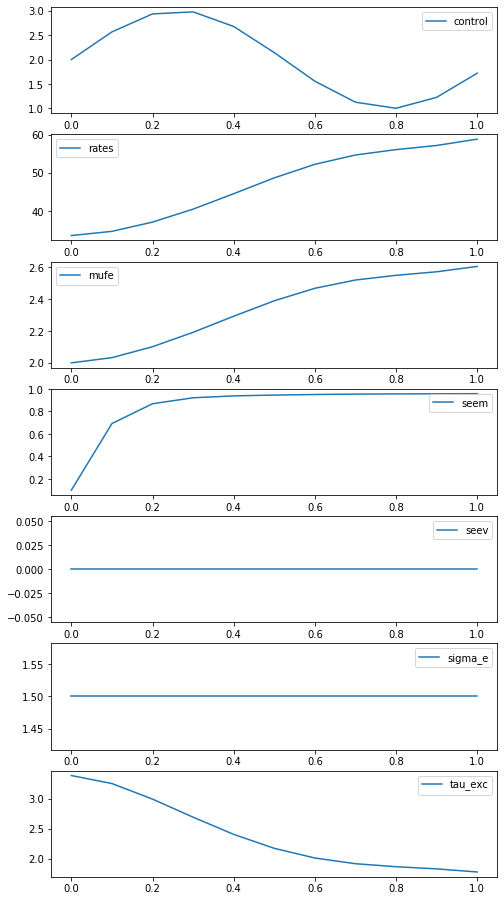

In [127]:
dur = 1.

a.params.duration = dur
a.params.ext_exc_current = 1.
a.params.mufe_init = np.array( [2.] )
target = a.getZeroTarget()
control1 = a.getZeroControl()

control1[0,0,:] += 2.
control1[0,0,:] += np.sin(6.*np.arange(0,dur+a.params.dt,a.params.dt))

a.run(control=control1)

target[:,0,:] = a.state["rates_exc"][0,:]

fig, axes = plt.subplots(7, figsize=(8, 16))
axes[0].plot(a.t, control1[0,0,:], label="control")
axes[1].plot(a.t, a.state["rates_exc"][0,:], label="rates")
axes[2].plot(a.t, a.state["mufe"][0,:], label="mufe")
axes[3].plot(a.t, a.state["seem"][0,:], label="seem")
axes[4].plot(a.t, a.state["seev"][0,:], label="seev")
axes[5].plot(a.t, a.state["sigmae_f"][0,:], label="sigma_e")
axes[6].plot(a.t, a.state["tau_exc"][0,:], label="tau_exc")
for i in range(7):
    axes[i].legend()

print(target)

In [122]:
max_cntrl = 10. * 5.
start_step = 10.
cost_params = [1.0, 3.0, 0.0]

init_state_vars = np.array( [a.params.rates_exc_init, a.params.mufe_init, a.params.seem_init, a.params.seev_init] )
cost.setParams(cost_params[0], cost_params[1], cost_params[2])

control2 = a.getZeroControl()

max_it = 90

A1_bestControlA, A1_bestStateA, A1_costA, runtime = a.A1(control2, target, c_scheme, u_mat, u_scheme,
        max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
        t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

set cost params
RUN  0 , total integrated cost =  166.15680316853678
RUN  1 , total integrated cost =  7.627065342831791
RUN  2 , total integrated cost =  6.787778147935215
RUN  3 , total integrated cost =  6.690831591624411
RUN  4 , total integrated cost =  6.679654340558218
RUN  5 , total integrated cost =  6.672180725798121
RUN  6 , total integrated cost =  6.666898131147275
RUN  7 , total integrated cost =  6.662993476681673
RUN  8 , total integrated cost =  6.659977343644355
RUN  9 , total integrated cost =  6.65760714923396
RUN  10 , total integrated cost =  6.655709468854808
RUN  11 , total integrated cost =  6.654182579773541
RUN  12 , total integrated cost =  6.652928812032046
RUN  13 , total integrated cost =  6.651891558766505
RUN  14 , total integrated cost =  6.651034435820372
RUN  15 , total integrated cost =  6.6503193617951375
RUN  16 , total integrated cost =  6.64972781050399
RUN  17 , total integrated cost =  6.6492376626
RUN  18 , total integrated cost =  6.64883177

In [ ]:
""" 
RUN  90 , total integrated cost =  6.646832944697234
Improved over  90  iterations by  95.99966247668162  percent.
final grad =  [[[ 0.00038666 -0.0015638  -0.00214014 -0.00157718 -0.00087272
   -0.00075252 -0.00100042 -0.00094842 -0.00024601 -0.00066022
    0.        ]]]
    
RUN  90 , total integrated cost =  6.646832944697234
Improved over  90  iterations by  95.99966247668162  percent.
final grad =  [[[ 0.00038666 -0.0015638  -0.00214014 -0.00157718 -0.00087272
   -0.00075252 -0.00100042 -0.00094842 -0.00024601 -0.00066022
    0.        ]]]
"""
diff = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]

plt.plot(a.t, diff)
plt.show()

[[[0.02199471 0.06172702 0.06184247 0.06099045 0.05911415 0.05614811
   0.05201767 0.0466383  0.03991474 0.03174009 0.02199471]]]


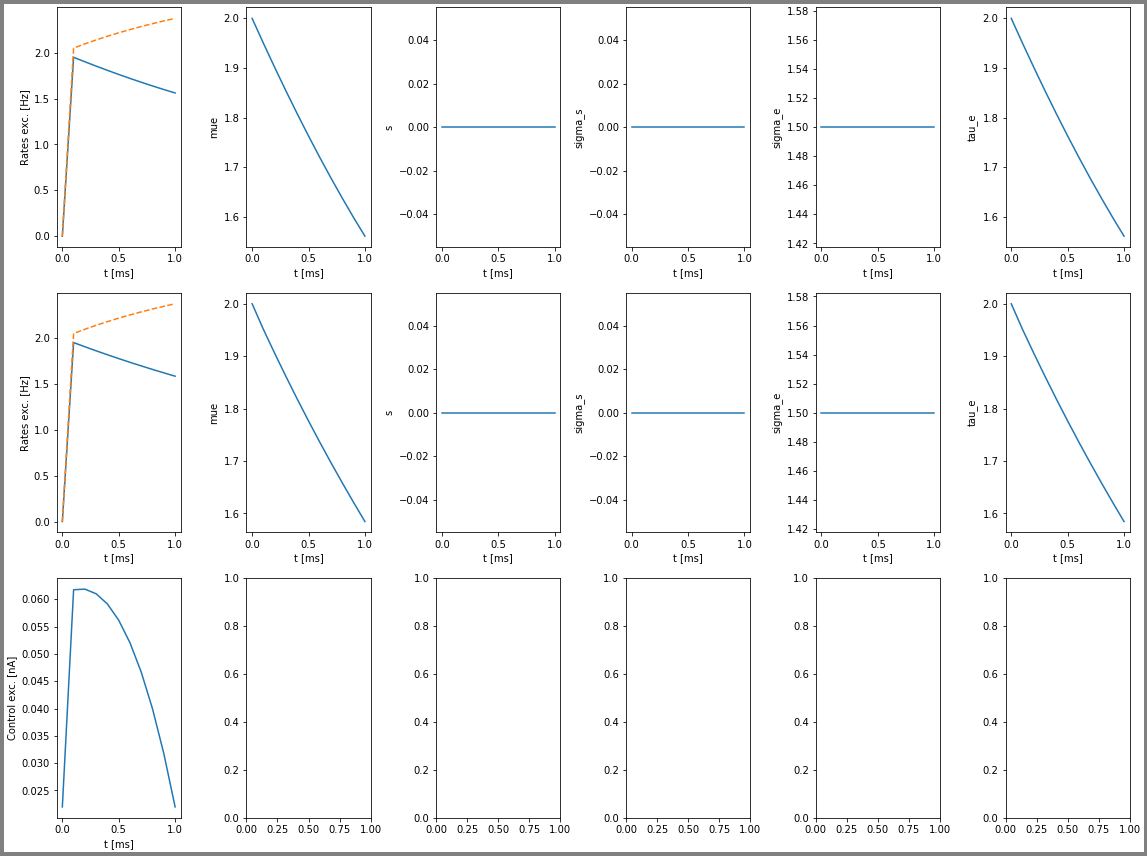

In [21]:
print(A1_bestControlA)
plotFunc.plot_control(a, A1_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'simp')

In [123]:
control3 = control2.copy()
control3[:,:,0] = A1_bestControlA[:,:,0]
control3[:,:,-1] = A1_bestControlA[:,:,-1]

max_it = 40

A2_bestControlA, A2_bestStateA, A2_costA, A2_runtimeA = a.A2(control3, target, max_iteration_ = max_it,
        tolerance_ = tol, include_timestep_ = incl_step, start_step_ = start_step, test_step_ = test_step,
        max_control_ = max_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post)

start ind =  1
RUN  0 , total integrated cost:  137.97696656063158
Using initial step.
RUN  1 , total integrated cost:  43.023715304726586
RUN  2 , total integrated cost:  14.015527814853177
RUN  3 , total integrated cost:  8.697575385391492
RUN  4 , total integrated cost:  7.409711808778921
RUN  5 , total integrated cost:  7.039020274411315
RUN  6 , total integrated cost:  6.9075113110762665
RUN  7 , total integrated cost:  6.841750835529338
RUN  8 , total integrated cost:  6.795575440172804
RUN  9 , total integrated cost:  6.75786433841578
RUN  10 , total integrated cost:  6.726577328915657
RUN  11 , total integrated cost:  6.701746253247533
RUN  12 , total integrated cost:  6.683014183422713
change helped, counter =  1
change helped, counter =  1
RUN  13 , total integrated cost:  6.669751287574237
RUN  14 , total integrated cost:  6.660879930370246
change helped, counter =  1
change helped, counter =  1
change helped, counter =  1
RUN  15 , total integrated cost:  6.655203869539552


[[[0.         0.00593561 0.00614251 0.00635893 0.0054356  0.00451951
   0.00360933 0.00270356 0.00180096 0.00090023 0.        ]]]


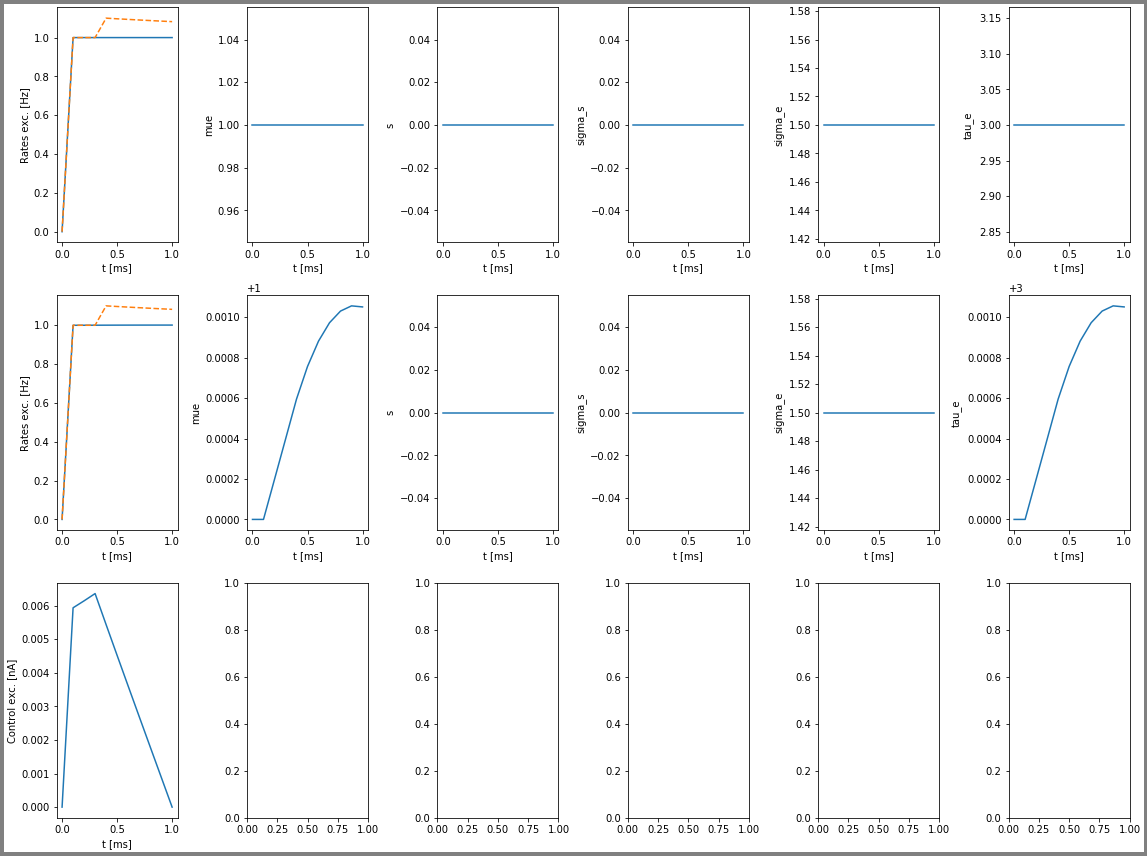

In [277]:
print(A2_bestControlA)
plotFunc.plot_control(a, A2_bestControlA, dur, dur_pre, dur_post, init_state_vars, target,
                      path, filename_ = 'a2simp')

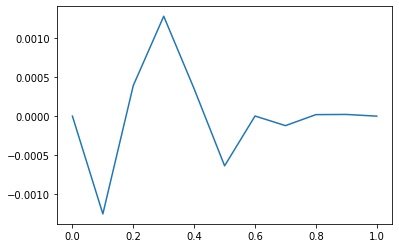

In [124]:
diff = A2_bestControlA[0,0,:] - A1_bestControlA[0,0,:]

plt.plot(a.t, diff)
plt.show()

In [4]:
gradient_r = np.zeros(( len(a.params.Irange), len(a.params.sigmarange), 3 ))

sigma = a.params.sigmarange[0]
mu = a.params.Irange[0]

for sigma in range(len(a.params.sigmarange)-3):
    for mu in range(len(a.params.Irange)-1):
        res0 = jac_aln.der_mu_up(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_r)
        res1 = jac_aln.der_mu_down(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_r)
        res2 = jac_aln.der_sigma(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_r)
        gradient_r[mu, sigma, 0] = res0
        gradient_r[mu, sigma, 1] = res1
        gradient_r[mu, sigma, 2] = res2
        
def getindex(lower, upper, length, x_):
    return int( (x_ - lower) * (length-1) / (upper - lower) )

def get_value(lower, upper, length, index_):
    return lower + index_ * (upper - lower) / (length-1)

[0.5 1.5 2.5 3.5 4.5 5.5 6.5]
indices mu =  [65, 109, 152, 196, 239, 283, 327]


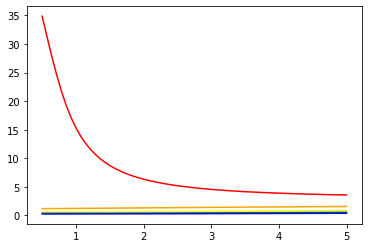

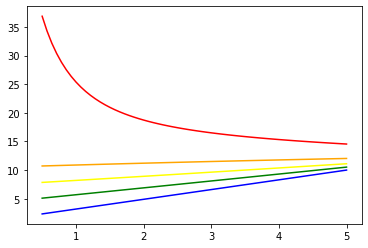

92


In [27]:
mu, sig = 1.1, 1.5

index_mu_ = getindex(a.params.Irange[0], a.params.Irange[-1], len(a.params.Irange), mu)
index_sigma_ = getindex(a.params.sigmarange[0], a.params.sigmarange[-1], len(a.params.sigmarange), sig)

def tau_func_sigma(mu, sigma):
    mu_shift = - 1.1
    sigma_scale = 0.5
    mu_scale = - 10
    mu_scale1 = - 3
    y_shift = 15.
    sigma_shift = 1.4
    return sigma_scale * (mu_shift+mu) * sigma + mu_scale1 * mu + y_shift + np.exp( mu_scale * (mu_shift + mu) / (sigma + sigma_shift) )    
    return (mu_shift+mu) * sigma + mu_scale * mu + y_shift + np.exp( mu_scale * (mu_shift + mu) / (sigma + sigma_shift) )

mu = np.arange(0.5, 7., 1.)
print(mu)
ind_mu = []
for m in mu:
    ind_mu.append(getindex(a.params.Irange[0], a.params.Irange[-1], len(a.params.Irange), m) )
print("indices mu = ", ind_mu)

plt.plot(a.params.sigmarange, a.params.precalc_tau_mu[ind_mu[0],:], color = "red")
plt.plot(a.params.sigmarange, a.params.precalc_tau_mu[ind_mu[1],:], color = "orange")
plt.plot(a.params.sigmarange, a.params.precalc_tau_mu[ind_mu[2],:], color = "yellow")
plt.plot(a.params.sigmarange, a.params.precalc_tau_mu[ind_mu[3],:], color = "green")
plt.plot(a.params.sigmarange, a.params.precalc_tau_mu[ind_mu[4],:], color = "blue")
plt.show()

#plt.plot(a.params.Irange, a.params.precalc_r[:, index_sigma_+45])
#plt.plot(a.params.Irange, a.params.precalc_r[:, index_sigma_-15])
plt.plot(a.params.sigmarange, tau_func_sigma(mu[0], a.params.sigmarange), color = "red" )
plt.plot(a.params.sigmarange, tau_func_sigma(mu[1], a.params.sigmarange), color = "orange" )
plt.plot(a.params.sigmarange, tau_func_sigma(mu[2], a.params.sigmarange), color = "yellow" )
plt.plot(a.params.sigmarange, tau_func_sigma(mu[3], a.params.sigmarange), color = "green" )
plt.plot(a.params.sigmarange, tau_func_sigma(mu[4], a.params.sigmarange), color = "blue" )
plt.show()

for m in range(len(a.params.Irange)):
    if a.params.precalc_tau_mu[m,0] < a.params.precalc_tau_mu[m,-1]:
        print(m)
        break

[0.5 0.7 0.9 1.1 1.3 1.5 1.7 1.9 2.1 2.3]
indices mu =  [65, 74, 82, 91, 100, 109, 117, 126, 135, 143]
[0.5 0.7 0.9 1.1 1.3 1.5 1.7 1.9 2.1 2.3]
indices sigma =  [0, 2, 5, 8, 11, 13, 16, 19, 22, 25]


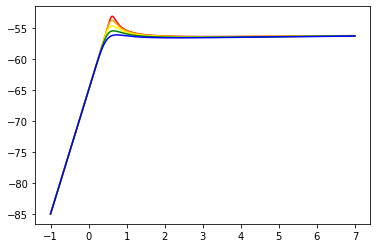

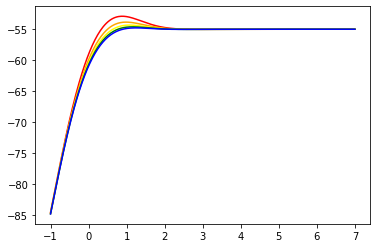

92


In [150]:
def V_func(mu, sigma):
    y_scale1 = 30.
    mu_shift1 = 1.
    y_shift = -85.
    y_scale2 = 2.
    mu_shift2 = 0.5
    return y_shift + y_scale1 * np.tanh( mu + mu_shift1 ) + y_scale2 * np.exp( - ( mu - mu_shift2 )**2 ) / sigma

mu = np.arange(0.5, 2.5, 0.2)
print(mu)
ind_mu = []
for m in mu:
    ind_mu.append(getindex(a.params.Irange[0], a.params.Irange[-1], len(a.params.Irange), m) )
print("indices mu = ", ind_mu)

sigma = np.arange(0.5, 2.5, 0.2)
print(sigma)
ind_sigma = []
for s in sigma:
    ind_sigma.append(getindex(a.params.sigmarange[0], a.params.sigmarange[-1], len(a.params.sigmarange), s) )
print("indices sigma = ", ind_sigma)

plt.plot(a.params.Irange, a.params.precalc_V[:,ind_sigma[0]], color = "red")
plt.plot(a.params.Irange, a.params.precalc_V[:,ind_sigma[1]], color = "orange")
plt.plot(a.params.Irange, a.params.precalc_V[:,ind_sigma[2]], color = "yellow")
plt.plot(a.params.Irange, a.params.precalc_V[:,ind_sigma[3]], color = "green")
plt.plot(a.params.Irange, a.params.precalc_V[:,ind_sigma[4]], color = "blue")
plt.show()

#plt.plot(a.params.Irange, a.params.precalc_r[:, index_sigma_+45])
#plt.plot(a.params.Irange, a.params.precalc_r[:, index_sigma_-15])
plt.plot(a.params.Irange, V_func(a.params.Irange, sigma[0]), color = "red" )
plt.plot(a.params.Irange, V_func(a.params.Irange, sigma[1]), color = "orange" )
plt.plot(a.params.Irange, V_func(a.params.Irange, sigma[2]), color = "yellow" )
plt.plot(a.params.Irange, V_func(a.params.Irange, sigma[3]), color = "green" )
plt.plot(a.params.Irange, V_func(a.params.Irange, sigma[4]), color = "blue" )
plt.show()

for m in range(len(a.params.Irange)):
    if a.params.precalc_tau_mu[m,0] < a.params.precalc_tau_mu[m,-1]:
        print(m)
        break

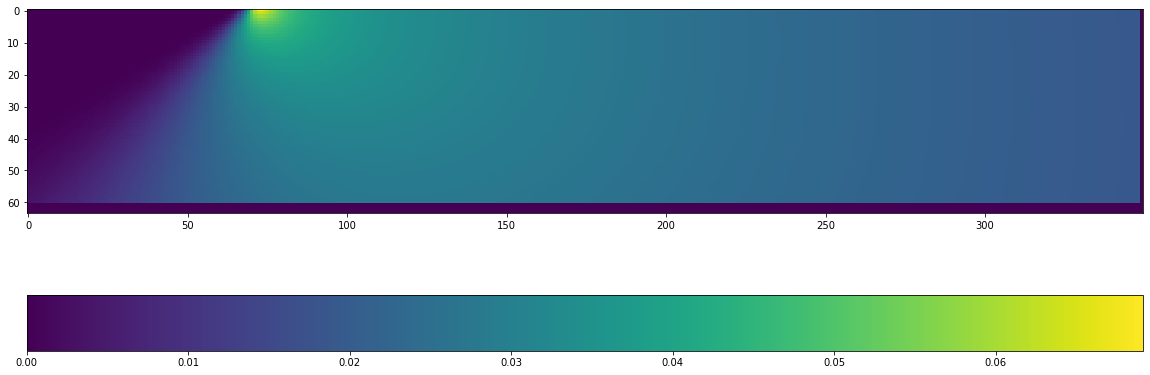

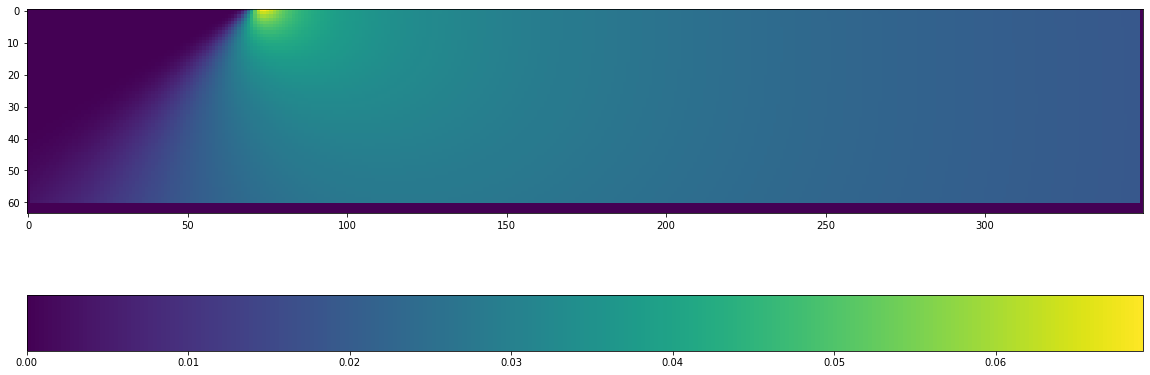

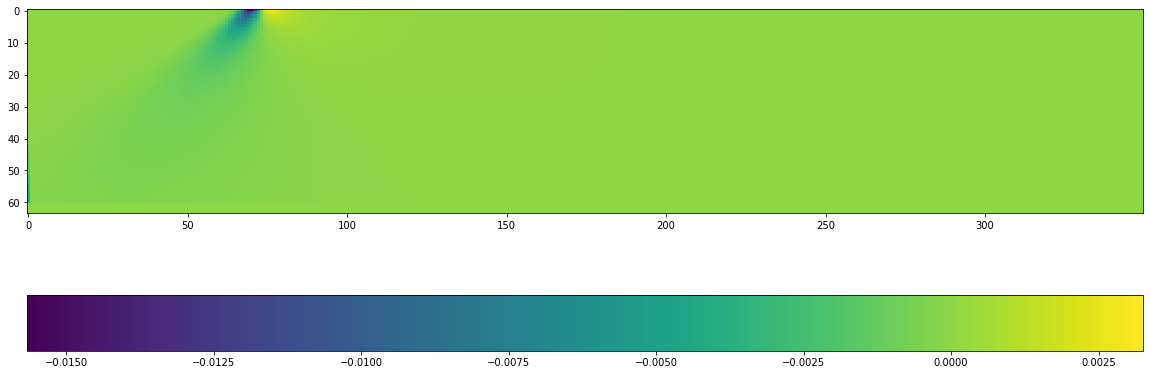

In [349]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,0].T)
plt.colorbar(orientation="horizontal")
#plt.show()

plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,1].T)
plt.colorbar(orientation="horizontal")
#plt.show()

plt.figure(figsize=(20,10))
plt.imshow(gradient_r[:,:,1].T - gradient_r[:,:,0].T)
plt.colorbar(orientation="horizontal")
plt.show()

In [355]:
gradient_tau = np.zeros(( len(a.params.Irange), len(a.params.sigmarange), 3 ))

sigma = a.params.sigmarange[0]
mu = a.params.Irange[0]

for sigma in range(len(a.params.sigmarange)-3):
    for mu in range(len(a.params.Irange)-1):
        res0 = jac_aln.der_mu_up(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_tau_mu)
        res1 = jac_aln.der_mu_down(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_tau_mu)
        res2 = jac_aln.der_sigma(a, a.params.sigmarange[sigma], a.params.Irange[mu], 0, a.params.precalc_tau_mu)
        gradient_tau[mu, sigma, 0] = res0
        gradient_tau[mu, sigma, 1] = res1
        gradient_tau[mu, sigma, 2] = res2

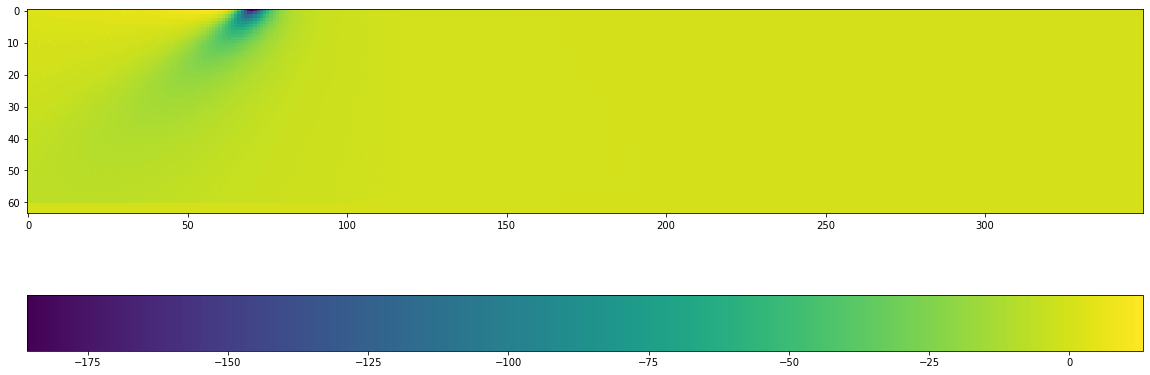

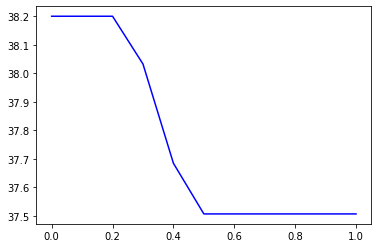

[38.19982642 38.19982642 38.19982642 38.03231443 37.68451449 37.50693233
 37.50693233 37.50693233 37.50693233 37.50693233 37.50693233]
[-4.3625  -4.3625  -4.3625  -3.92625 -3.49    -3.49    -3.49    -3.49
 -3.49    -3.49    -3.49   ]


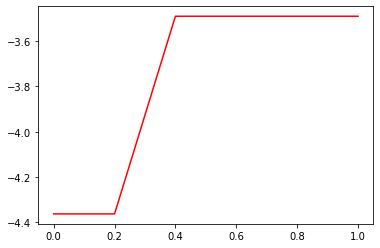

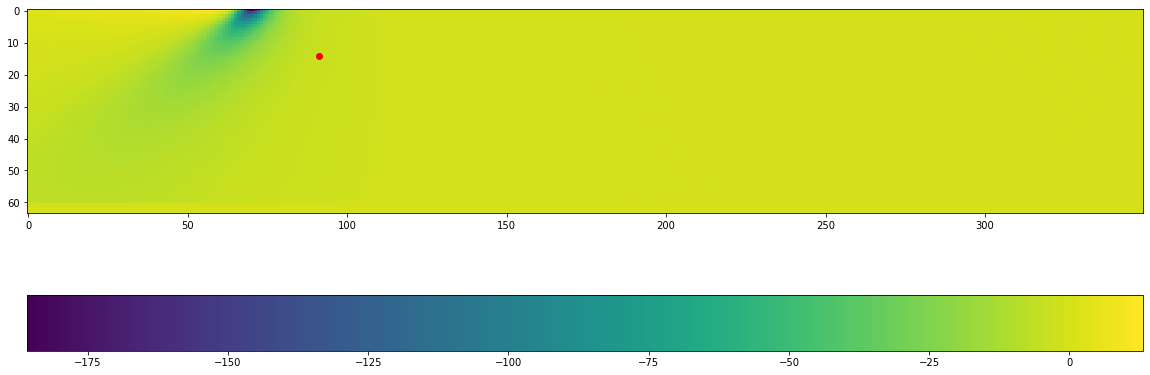

In [356]:
plt.figure(figsize=(20,10))
plt.imshow(gradient_tau[:,:,0].T)
plt.colorbar(orientation="horizontal")
plt.show()

grad_r = np.zeros(( len(a.state["mufe"][0,:]) ))
grad_tau = np.zeros(( len(a.state["mufe"][0,:]) ))
for m in range(len(a.state["mufe"][0,:])):
    index_ = getindex(a.params.Irange[0], a.params.Irange[-1], len(a.params.Irange), a.state["mufe"][0,m])
    index_sigma_ = getindex(a.params.sigmarange[0], a.params.sigmarange[-1], len(a.params.sigmarange), 1.5)
    grad_r[m] = gradient_r[index_, index_sigma_, 0]
    grad_tau[m] = gradient_tau[index_, index_sigma_, 0]
    
plt.plot(a.t, grad_r*1e3, c="blue")
plt.show()
print(grad_r*1e3)
print(grad_tau)
plt.plot(a.t, grad_tau, c="red")
plt.show()


threshold = 0.02
large_g = gradient_tau.copy()
large_g[np.abs(large_g) < threshold] = 0

plt.figure(figsize=(20,10))
plt.imshow(large_g[:,:,0].T)
plt.plot(index_, index_sigma_, "o", c="red")
plt.colorbar(orientation="horizontal")
plt.show()